In [ ]:
from google.colab import files
files.upload()

Saving Lenna.png to Lenna (2).png


{'Lenna (2).png': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x02\x00\x00\x00\x02\x00\x08\x02\x00\x00\x00{\x1aC\xad\x00\x00\x00\x01sRGB\x00\xae\xce\x1c\xe9\x00\x07:\xa1IDATx\xda\xec\xe1]\x92m[\x92\x1d\xe6\x8d\xe1\xees\xae\xb5#\xe2\x9c{3\xab \x08\xe4\x8bZ \xa3\x8cFQ\xa4\xf1O%\xa3\x99:#\xa3\x00\xeaU\rP\xe3\xd4\x00Q\xa4\xc1\x00\x92H \xab\xb2\xf2\xde{"\xf6^kNw\x1fJ\xb5\x03\xf9}\xfc\xd7\xff\xaf\xff\'\x80\xc2\tm\xb7\x0b\xaf\xb4\xc7\xa1$\xa6w^\xae\xa3\xb4;\x7f\xf8\xe3\xbd\x92\xbd\x16\xc6B\r\x1e\'x\xf3sc$\xabj\x1cUts\xabm\xfb\x99\xe3\x9fBO\xf5\x9b\xc7\xa7\xe5\xeac\xfa\xaa:~\xb6~\xda\xfb\x87\xbd\xfe\xc1\x8e\xbf\x01o*\x9b\xc3\x8f`\xc3\xa7\xa5\xba\x13\x13MT.\xe3{\xe8\xb5\xba\x06\xefW\xf5\xa3~\xfdw\xcb\x8e>\xfe7\xeb\xcf\xff\xf8\xfc\\\xfa\xe5\xf3\xd78~|\xae\xfdu\x95\xf1\xea\xd8}\xd8\xfa\xc5>~\xff\x18{\xaf\xafq\x1c\xca\x8e\x08R!\x03\x92e\xe3\xf4\xb2\xcdl\xc9\xd0\xbb\x05\x9c\xb3\xe1\xb3\xab\xd5l\x13@VX$\nU\xf4(\x0c\xe7-\x1d\x89\xa5\xbdi6\xbah\xa3\xa2\x06&\xde\xdc?\x97\x85\xf9\xf0\x08"3\xaf\xfdx\x7f

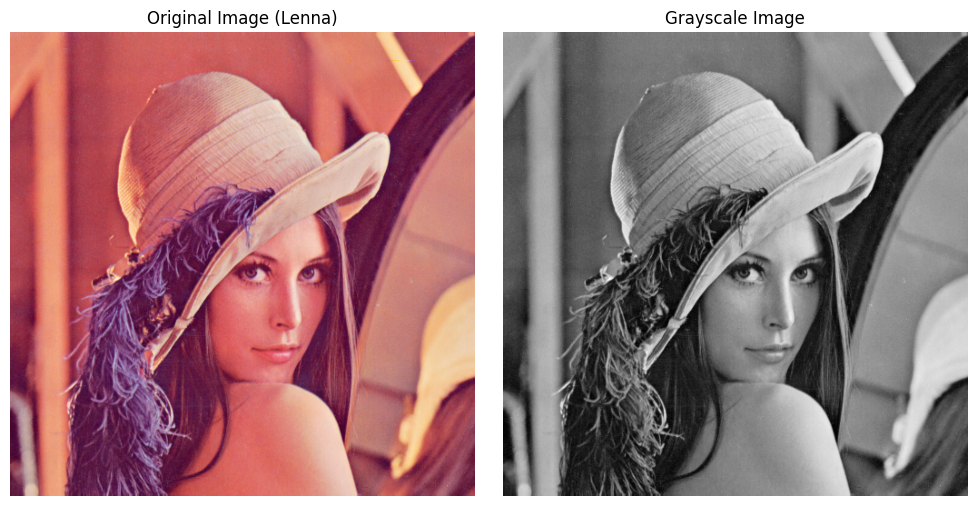

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("Lenna.png")

# Convert BGR → RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Display side by side
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original Image (Lenna)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

plt.tight_layout()
plt.show()



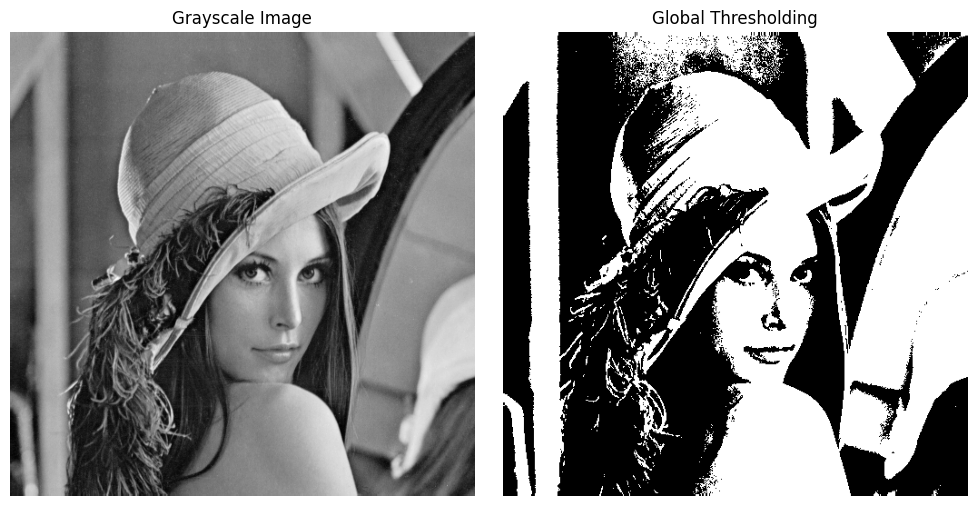

In [ ]:
# Global Thresholding
_, global_thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# Display Grayscale vs Global Threshold
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(global_thresh, cmap='gray')
plt.title("Global Thresholding")
plt.axis("off")

plt.tight_layout()
plt.show()


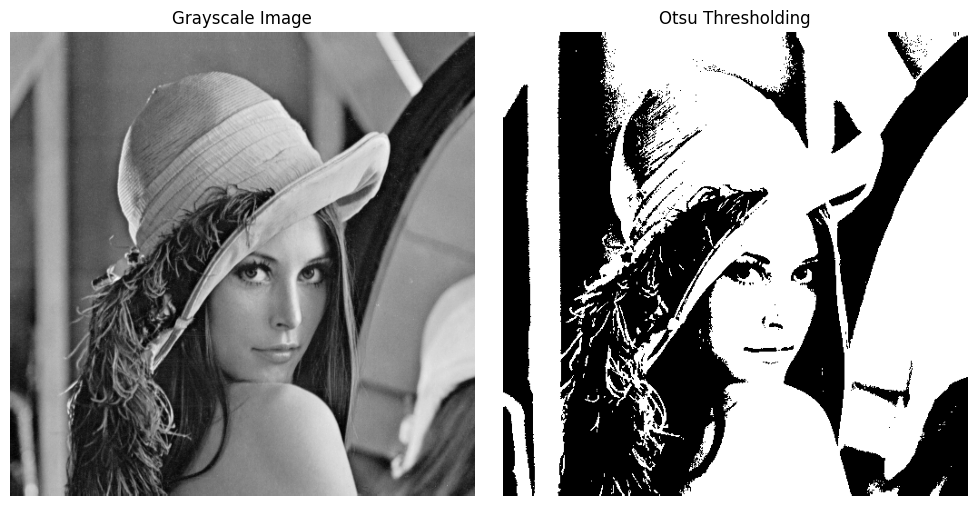

In [ ]:
# Otsu Thresholding
_, otsu_thresh = cv2.threshold(
    gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# Display Grayscale vs Otsu Threshold
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(otsu_thresh, cmap='gray')
plt.title("Otsu Thresholding")
plt.axis("off")

plt.tight_layout()
plt.show()


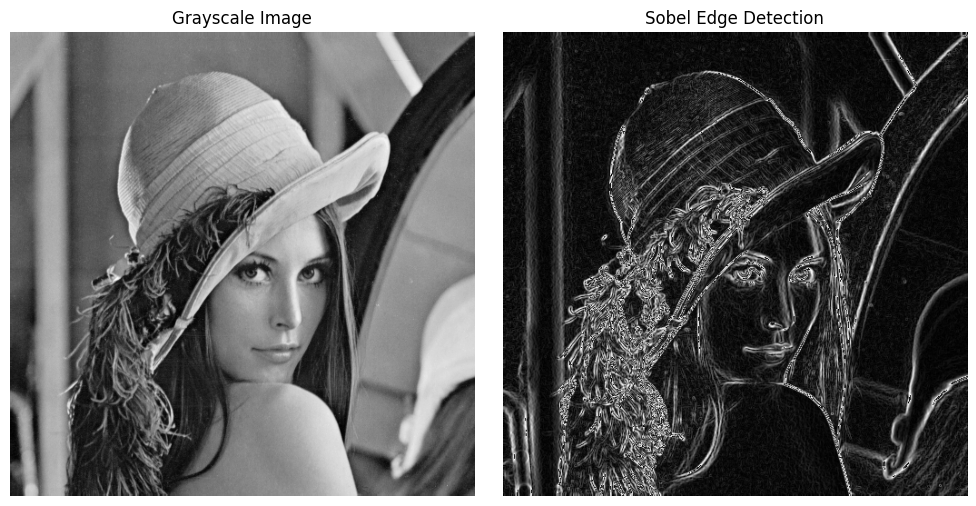

In [ ]:
# Sobel Edge Detection
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

# Gradient magnitude
sobel_mag = (sobel_x**2 + sobel_y**2) ** 0.5
sobel_mag = sobel_mag.astype('uint8')

# Display Grayscale vs Sobel
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(sobel_mag, cmap='gray')
plt.title("Sobel Edge Detection")
plt.axis("off")

plt.tight_layout()
plt.show()


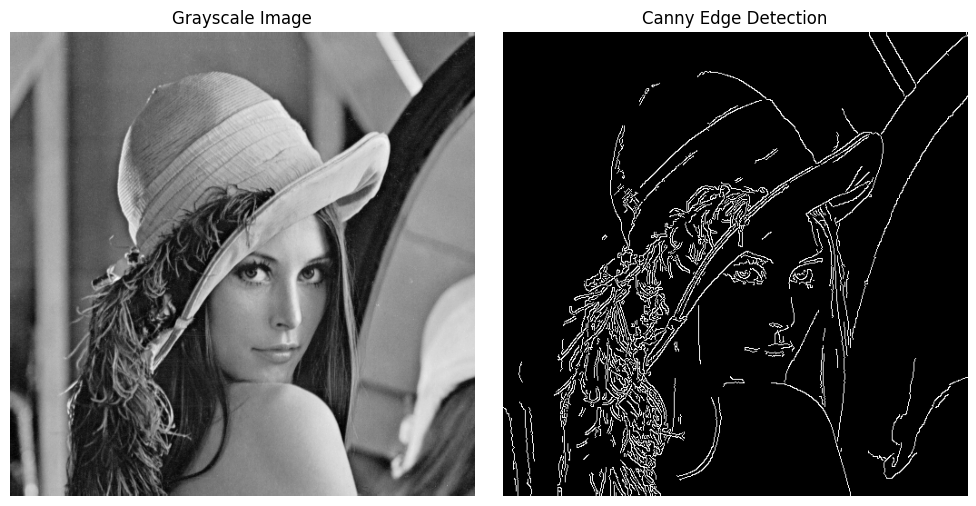

In [ ]:
# Canny Edge Detection
canny_edges = cv2.Canny(gray, 100, 200)

# Display Grayscale vs Canny
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(canny_edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis("off")

plt.tight_layout()
plt.show()


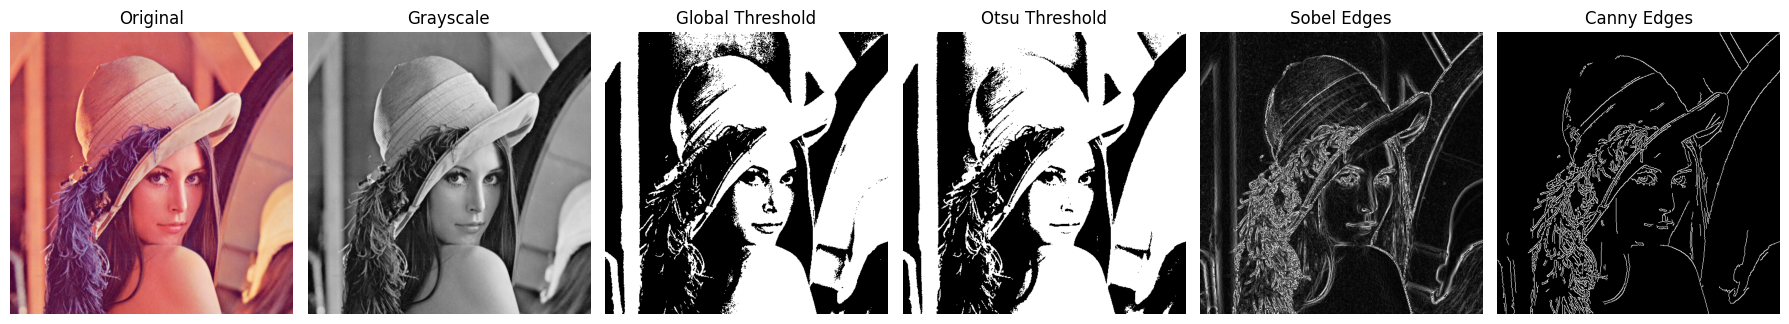

In [ ]:
plt.figure(figsize=(18,6))

titles = [
    "Original",
    "Grayscale",
    "Global Threshold",
    "Otsu Threshold",
    "Sobel Edges",
    "Canny Edges"
]

images = [
    img_rgb,
    gray,
    global_thresh,
    otsu_thresh,
    sobel_mag,
    canny_edges
]

for i in range(len(images)):
    plt.subplot(1, 6, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


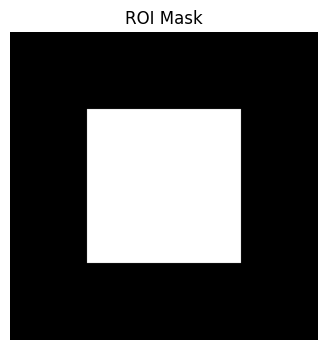

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Create a black mask
mask = np.zeros(gray.shape, dtype=np.uint8)

# Define ROI (x, y, width, height)
h, w = gray.shape
x, y = int(w*0.25), int(h*0.25)
roi_w, roi_h = int(w*0.5), int(h*0.5)

# Make ROI white
mask[y:y+roi_h, x:x+roi_w] = 255

# Display mask
plt.figure(figsize=(4,4))
plt.imshow(mask, cmap='gray')
plt.title("ROI Mask")
plt.axis("off")
plt.show()


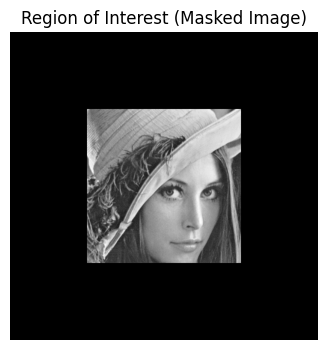

In [ ]:
roi_image = cv2.bitwise_and(gray, gray, mask=mask)

plt.figure(figsize=(4,4))
plt.imshow(roi_image, cmap='gray')
plt.title("Region of Interest (Masked Image)")
plt.axis("off")
plt.show()


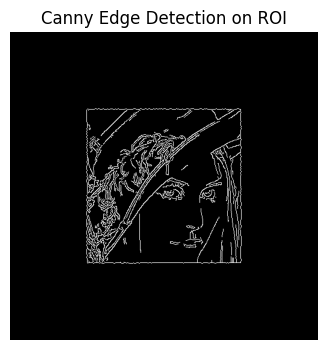

In [ ]:
roi_canny = cv2.Canny(roi_image, 100, 200)

plt.figure(figsize=(4,4))
plt.imshow(roi_canny, cmap='gray')
plt.title("Canny Edge Detection on ROI")
plt.axis("off")
plt.show()
